In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
denuncias_modalidad = pd.read_csv('../data/processed/denuncias_modalidad.csv')
proporciones_mujeres = pd.read_csv('../data/processed/proporciones_distritales_mujeres_hogares.csv')
poblacion_distrital = pd.read_csv('../data/processed/poblacion_por_distrito.csv')

In [3]:
proporciones_mujeres = proporciones_mujeres.iloc[:,1:]

In [4]:
## filtrar por año 2025

denuncias_2025 = denuncias_modalidad[denuncias_modalidad['anio'] == 2025]
proporciones_mujeres_2025 = proporciones_mujeres
poblacion_distrital_2025 = poblacion_distrital[poblacion_distrital['anio'] == 2025]

In [5]:
base_final = denuncias_2025.merge(proporciones_mujeres_2025, on='ubigeo', how='inner')
base_final = base_final.merge(poblacion_distrital_2025, on='ubigeo', how='inner')

In [6]:
base_final.drop(columns=['departamento_y', 'provincia_y', 'distrito_y', 'anio_y'], inplace=True)
base_final.rename(columns={'departamento_x': 'departamento', 'provincia_x': 'provincia', 'distrito_x': 'distrito', 'anio_x': 'anio'}, inplace=True)

In [7]:
base_final.describe()

,anio,ubigeo,amenaza_grave,coaccion_grave,maltrato_sin_lesion,violencia_economica_o_patrimonial,violencia_fisica,violencia_fisica_y_psicologica,violencia_psicologica,violencia_sexual,...,prop_edu_basica,prop_alfabetizacion_funcional,prop_lengua_materna_nativa,prop_tic_uso_internet,prop_tic_celular_propio,prop_salud_enfermedad_cronica,prop_tiene_limitacion,prop_tiene_seguro,media_edad,población
count,1131.0,1131.000000,1131.000000,1131.000000,1131.0,1131.000000,1131.000000,1131.0,1131.000000,1131.000000,...,1131.000000,1131.000000,1131.000000,1112.000000,1131.000000,1131.000000,1131.000000,1131.000000,1131.000000,1.131000e+03
mean,2025.0,115747.170645,0.223696,0.041556,0.0,8.761273,93.847038,0.0,155.926614,2.143236,...,0.664334,0.862817,0.319650,0.735433,0.826227,0.610332,0.081492,0.952829,48.691335,2.877127e+04
std,0.0,67783.635245,2.694210,0.250746,0.0,42.593090,255.636600,0.0,469.789020,8.479585,...,0.184579,0.142456,0.367752,0.264244,0.161730,0.180176,0.099986,0.074101,6.878287,7.669691e+04
min,2025.0,10101.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.178518,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,29.333333,2.090000e+02
25%,2025.0,55604.500000,0.000000,0.000000,0.0,0.000000,4.000000,0.0,4.000000,0.000000,...,0.539751,0.803027,0.000000,0.611393,0.755951,0.500000,0.000000,0.924046,43.790311,3.454500e+03
50%,2025.0,120116.000000,0.000000,0.000000,0.0,0.000000,15.000000,0.0,22.000000,0.000000,...,0.664475,0.907195,0.127456,0.812602,0.872601,0.613279,0.053614,1.000000,47.576771,8.128000e+03
75%,2025.0,160403.000000,0.000000,0.000000,0.0,2.000000,62.500000,0.0,86.500000,1.000000,...,0.798917,0.968070,0.635478,0.937788,0.936820,0.734883,0.123852,1.000000,53.007294,2.076400e+04
max,2025.0,250401.000000,80.000000,3.000000,0.0,553.000000,3337.000000,0.0,5923.000000,105.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.600000,1.000000,74.750000,1.282635e+06


In [8]:
base_final.shape

(1131, 38)

## Creación de Tasa de Violencia contra la Mujer

In [9]:
base_final['TVM'] = base_final['total'] / base_final['población'] * 1000

## Crear índice de Vulnerabilidad

In [10]:
base_final.columns

Index(['anio', 'ubigeo', 'departamento', 'provincia', 'distrito',
       'amenaza_grave', 'coaccion_grave', 'maltrato_sin_lesion',
       'violencia_economica_o_patrimonial', 'violencia_fisica',
       'violencia_fisica_y_psicologica', 'violencia_psicologica',
       'violencia_sexual', 'total', 'prop_viv_tipo', 'prop_tic_celular',
       'prop_tic_internet', 'prop_agua_todos_dias', 'prop_serv_electricidad',
       'prop_nbi_vivienda', 'prop_nbi_hacinamiento', 'prop_nbi_sshh',
       'prop_nbi_educacion', 'prop_nbi_dependencia', 'prop_es_jefe',
       'prop_es_mujer', 'prop_en_pareja', 'prop_edu_superior',
       'prop_edu_basica', 'prop_alfabetizacion_funcional',
       'prop_lengua_materna_nativa', 'prop_tic_uso_internet',
       'prop_tic_celular_propio', 'prop_salud_enfermedad_cronica',
       'prop_tiene_limitacion', 'prop_tiene_seguro', 'media_edad', 'población',
       'TVM'],
      dtype='str')

In [11]:
base_final["prop_sin_agua_diaria"] = 1 - base_final["prop_agua_todos_dias"]
base_final["prop_sin_electricidad"] = 1 - base_final["prop_serv_electricidad"]
base_final["prop_sin_internet"] = 1 - base_final["prop_tic_internet"]

variables_vulnerabilidad = [
    "prop_nbi_vivienda",
    "prop_nbi_hacinamiento",
    "prop_nbi_sshh",
    "prop_nbi_educacion",
    "prop_nbi_dependencia",
    "prop_sin_agua_diaria",
    "prop_sin_electricidad",
    "prop_sin_internet"
]

base_final["indice_vulnerabilidad"] = (
    base_final[variables_vulnerabilidad].mean(axis=1)
)

base_final['indice_vulnerabilidad'] = base_final['indice_vulnerabilidad'].fillna(0).astype('float64')

base_final.head()

,anio,ubigeo,departamento,provincia,distrito,amenaza_grave,coaccion_grave,maltrato_sin_lesion,violencia_economica_o_patrimonial,violencia_fisica,...,prop_salud_enfermedad_cronica,prop_tiene_limitacion,prop_tiene_seguro,media_edad,población,TVM,prop_sin_agua_diaria,prop_sin_electricidad,prop_sin_internet,indice_vulnerabilidad
0,2025,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,0,0,0,62,257,...,0.679256,0.112473,0.980843,47.066860,41843.0,20.122840,0.268047,0.037552,0.072248,0.057064
1,2025,10104,AMAZONAS,CHACHAPOYAS,CHETO,0,0,0,0,0,...,0.500000,0.000000,1.000000,47.250000,716.0,2.793296,0.000000,0.000000,0.000000,0.000000
2,2025,10106,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,0,0,0,0,3,...,0.714286,0.142857,1.000000,59.285714,1872.0,3.739316,0.000000,0.250000,0.250000,0.062500
3,2025,10109,AMAZONAS,CHACHAPOYAS,LA JALCA,0,0,0,0,15,...,0.579753,0.000000,1.000000,46.969642,3279.0,14.028667,0.000000,0.067488,0.134975,0.082820
4,2025,10110,AMAZONAS,CHACHAPOYAS,LEIMEBAMBA,0,0,0,1,2,...,0.830911,0.027976,1.000000,52.438633,3716.0,2.421959,0.000000,0.162325,0.027054,0.043963


In [12]:
base_final.drop(columns = ['prop_sin_agua_diaria', 'prop_sin_electricidad', 'prop_sin_internet'], inplace=True)

In [13]:
base_final.indice_vulnerabilidad.describe()

count    1131.000000
mean        0.069281
std         0.064633
min         0.000000
25%         0.023138
50%         0.049949
75%         0.096962
max         0.478224
Name: indice_vulnerabilidad, dtype: float64

## 4. Visualización
Esta sección realiza un análisis exhaustivo de los datos, incluyendo:
- Visualizaciones geográficas por región (Perú y Lima)
- Análisis descriptivo por zona geográfica
- Correlaciones entre variables

### 4.1. Visualización Geográfica

In [14]:
# importar libreria
import geopandas as gpd

In [15]:
# correción de nombres de departamentos
base_final['departamento'] = base_final['departamento'].replace({'LIMA METROPOLITANA': 'LIMA',
                                                             'REGION LIMA': 'LIMA',
                                                             'PROV. CONST. DEL CALLAO': 'LIMA',})

In [16]:
ruta_departamentos = "../data/raw/DEPARTAMENTO.gpkg"

# Listar layers
layers = gpd.list_layers(ruta_departamentos)
print(layers)

# cargar el layer de departamentos
gdf = gpd.read_file(ruta_departamentos, layer=layers.iloc[0]['name'])


           name geometry_type
0  DEPARTAMENTO  MultiPolygon


#### Gráficos para Perú

In [17]:
peru = base_final.groupby("departamento").agg(TVM = ("TVM", "mean"), 
                                            violencia_fisica = ("violencia_fisica", "sum"),
                                            violencia_psicologica = ("violencia_psicologica", "sum"),
                                            violencia_sexual = ("violencia_sexual", "sum"),
                                            violencia_economica_o_patrimonial = ("violencia_economica_o_patrimonial", "sum")
                                            ).reset_index()

peru.head()

,departamento,TVM,violencia_fisica,violencia_psicologica,violencia_sexual,violencia_economica_o_patrimonial
0,AMAZONAS,5.969888,1162,1860,15,92
1,ANCASH,5.963181,3796,6661,39,403
2,APURIMAC,8.333669,2391,2681,15,70
3,AREQUIPA,11.230408,6972,11471,220,244
4,AYACUCHO,6.696081,2298,3795,8,119


In [18]:
peru_georreferenciado = peru.merge(
    gdf,
    left_on="departamento",
    right_on="nombdep",
    how="inner"
)

In [19]:
peru_georreferenciado_gdf = gpd.GeoDataFrame(
    peru_georreferenciado,
    geometry="geometry"
)

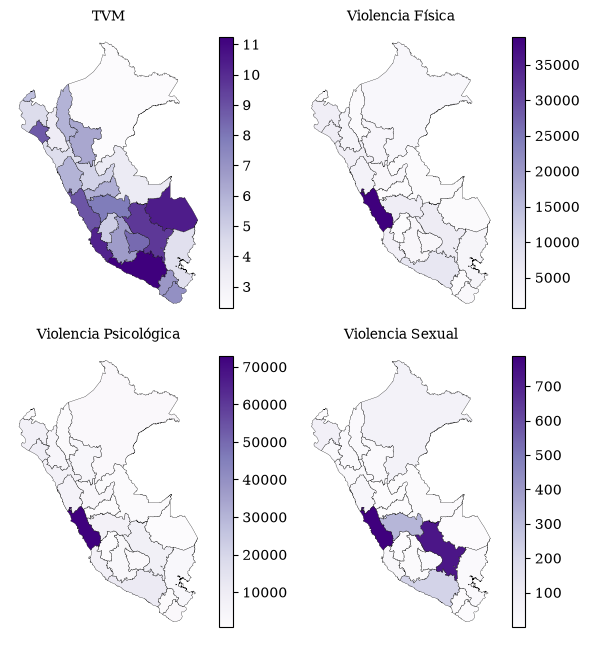

In [20]:
import matplotlib.pyplot as plt

# parámetros globales para formato IEEE
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 10,
    'figure.autolayout': True,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
})

# variables y titulos
variables = ['TVM', 'violencia_fisica', 'violencia_psicologica', 'violencia_sexual']
titulos = ['TVM', 'Violencia Física', 'Violencia Psicológica', 'Violencia Sexual']


fig, axes = plt.subplots(2, 2, figsize=(6, 8))
axes = axes.flatten() # Aplanar para iterar fácilmente

# graficar
for ax, var, title in zip(axes, variables, titulos):
    peru_georreferenciado_gdf.plot(
        column=var, 
        ax=ax, 
        legend=True,
        cmap='Purples',
        edgecolor='black',
        linewidth=0.2,
        legend_kwds={
            'orientation': "vertical", 
            'shrink': 0.6,
            'pad': 0.05
        }
    )
    
    ax.set_title(title)
    ax.set_axis_off()

# guardar
plt.savefig("mapa_violencia_general.png", dpi=300, bbox_inches='tight')

plt.show()

#### Gráficos para Lima

In [21]:
lima = base_final[base_final['provincia'] == 'LIMA'][['distrito', 'TVM', 'violencia_fisica', 'violencia_psicologica', 'violencia_sexual']].reset_index(drop=True)
lima.head()

,distrito,TVM,violencia_fisica,violencia_psicologica,violencia_sexual
0,LIMA,26.432846,2213,4340,78
1,ANCON,5.614431,235,310,6
2,ATE,9.725400,2464,4466,9
3,BARRANCO,13.301446,135,351,0
4,BREÑA,12.123258,344,719,8


In [22]:
ruta_distrito = "../data/raw/DISTRITO.gpkg"

# Listar los layers
layers = gpd.list_layers(ruta_distrito)
print(layers)

# Cargar layer de distritos
gdf = gpd.read_file(ruta_distrito, layer=layers.iloc[0]['name'])

# Filtrar donde la columna 'nombprov' sea igual a 'LIMA'
lima_gdf = gdf[gdf['nombprov'] == 'LIMA'].copy()

       name geometry_type
0  DISTRITO  MultiPolygon


In [23]:
lima_georreferenciado = lima.merge(
    lima_gdf,
    left_on="distrito",
    right_on="nombdist",
    how="inner"
)

In [24]:
lima_georreferenciado_gdf = gpd.GeoDataFrame(
    lima_georreferenciado,
    geometry="geometry"
)

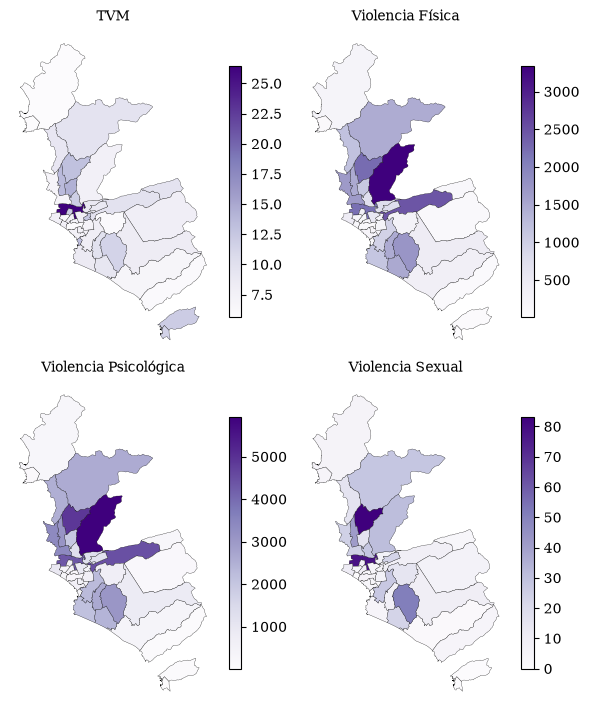

In [25]:
# definir vairables y titulos para los mapas de Lima
variables = ['TVM', 'violencia_fisica', 'violencia_psicologica', 'violencia_sexual']
titulos = ['TVM', 'Violencia Física', 'Violencia Psicológica', 'Violencia Sexual']

fig, axes = plt.subplots(2, 2, figsize=(6, 8))
axes = axes.flatten()

# graficar
for ax, var, title in zip(axes, variables, titulos):
    lima_georreferenciado_gdf.plot(
        column=var, 
        ax=ax, 
        legend=True,
        cmap='Purples',
        edgecolor='black',
        linewidth=0.2,
        legend_kwds={
            'orientation': "vertical", 
            'shrink': 0.6,
            'pad': 0.05
        }
    )
    
    ax.set_title(title)
    ax.set_axis_off() 

plt.savefig("mapa_violencia_lima.png", dpi=300, bbox_inches='tight')

plt.show()

### 4.2. Análisis Descriptivo - Enfoque en Lima

#### Filtrado de indicadores para Lima


In [26]:
base_lima = base_final[base_final['provincia'] == 'LIMA']
base_lima.describe()

,anio,ubigeo,amenaza_grave,coaccion_grave,maltrato_sin_lesion,violencia_economica_o_patrimonial,violencia_fisica,violencia_fisica_y_psicologica,violencia_psicologica,violencia_sexual,...,prop_lengua_materna_nativa,prop_tic_uso_internet,prop_tic_celular_propio,prop_salud_enfermedad_cronica,prop_tiene_limitacion,prop_tiene_seguro,media_edad,población,TVM,indice_vulnerabilidad
count,41.0,41.000000,41.000000,41.000000,41.0,41.000000,41.000000,41.0,41.000000,41.000000,...,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,4.100000e+01,41.000000,41.000000
mean,2025.0,150121.829268,4.804878,0.487805,0.0,136.756098,770.146341,0.0,1485.121951,15.341463,...,0.077901,0.804080,0.942865,0.610816,0.053995,0.926470,47.562400,2.537464e+05,9.349944,0.024952
std,0.0,12.837255,13.327077,0.925255,0.0,154.458373,800.976765,0.0,1499.864747,18.879367,...,0.071931,0.155694,0.036772,0.106292,0.041375,0.054166,4.901464,2.581012e+05,3.667964,0.034857
min,2025.0,150101.000000,0.000000,0.000000,0.0,0.000000,4.000000,0.0,11.000000,0.000000,...,0.000000,0.186915,0.853378,0.470531,0.000000,0.750000,31.000000,1.314000e+03,5.614431,0.000000
25%,2025.0,150111.000000,0.000000,0.000000,0.0,31.000000,162.000000,0.0,351.000000,5.000000,...,0.011734,0.733310,0.917939,0.539368,0.027874,0.909746,45.600000,7.155800e+04,7.093715,0.007074
50%,2025.0,150121.000000,1.000000,0.000000,0.0,69.000000,435.000000,0.0,863.000000,8.000000,...,0.053748,0.816106,0.944823,0.584408,0.045199,0.934121,46.814193,1.709980e+05,8.420499,0.018539
75%,2025.0,150133.000000,3.000000,1.000000,0.0,257.000000,1182.000000,0.0,2435.000000,23.000000,...,0.122715,0.917277,0.969565,0.661029,0.071997,0.964800,49.570661,3.803130e+05,11.415525,0.028916
max,2025.0,150143.000000,80.000000,3.000000,0.0,553.000000,3337.000000,0.0,5923.000000,83.000000,...,0.282022,1.000000,1.000000,1.000000,0.200000,1.000000,58.152980,1.282635e+06,26.432846,0.218750


#### Gráfico de dispersión del índice de Vulnerabilidad y la TVM

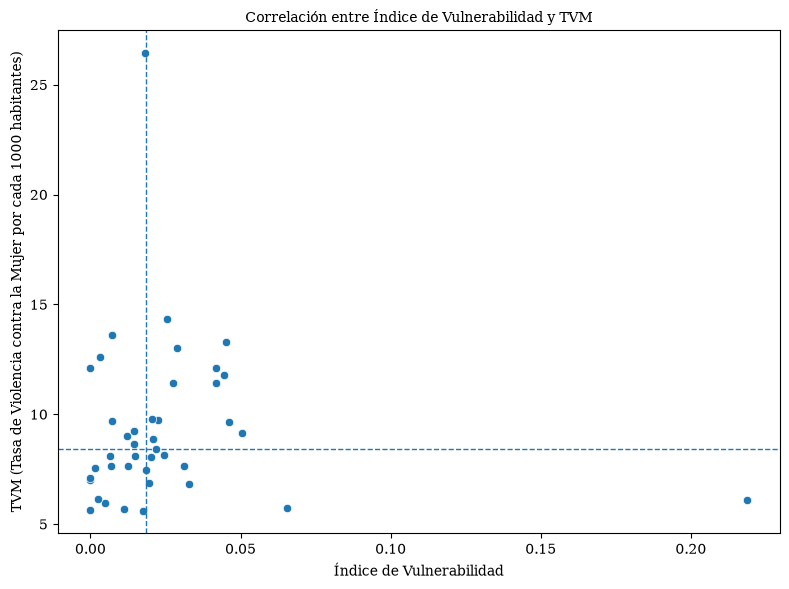

In [27]:
# mediana de TVM en Lima
mediana_tvm = base_lima['TVM'].median()

# mediana del indice de vulnerabilidad en Lima
mediana_vulnerabilidad = base_lima['indice_vulnerabilidad'].median()


## grafica de correlacion entre TVM e indice de vulnerabilidad
plt.figure(figsize=(8, 6))
sns.scatterplot(data=base_lima, x='indice_vulnerabilidad', y='TVM')
plt.title('Correlación entre Índice de Vulnerabilidad y TVM')
plt.xlabel('Índice de Vulnerabilidad')
plt.ylabel('TVM (Tasa de Violencia contra la Mujer por cada 1000 habitantes)')
plt.grid(False)
plt.axvline(
    mediana_vulnerabilidad,
    linestyle="--",
    linewidth=1
)
plt.axhline(
    mediana_tvm,
    linestyle="--",
    linewidth=1
)
plt.savefig("correlacion_vulnerabilidad_tvm.png", dpi=300, bbox_inches='tight')
plt.show()


### 4.3. Análisis de Correlaciones

#### Correlacion entre todas las variables

In [28]:
# separar variables predictoras y variable objetivo
X = base_lima.select_dtypes(include=["float64"]).drop(columns=["prop_es_mujer", "media_edad","población"])

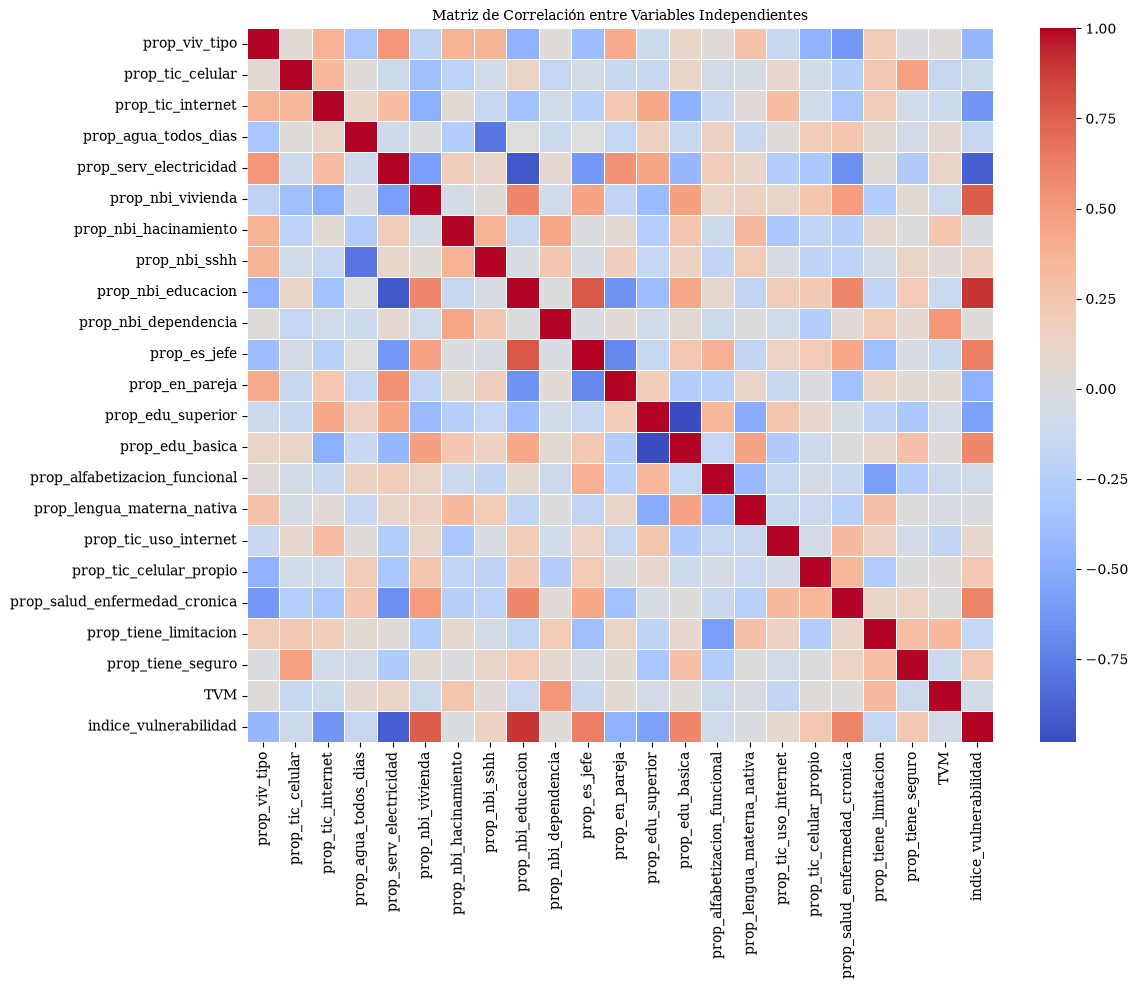

In [29]:
# generar matriz de correlación entre variables independientes
correlation_matrix = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Independientes")
plt.savefig("matriz_correlacion.png", dpi=300, bbox_inches='tight')
plt.show()

#### Correlación entre solo variables independientes

In [30]:
X = base_lima.select_dtypes(include=["float64"]).drop(columns=["TVM","prop_es_mujer", "media_edad","población"])
y = base_lima["TVM"]

In [31]:
correlation_matrix = X.corr()

# seleccionar solo variables con correlación mayor a 0.6
correlation_matrix_abs = correlation_matrix.abs()  # Tomar el valor absoluto para considerar tanto correlaciones positivas como negativas
high_correlation = correlation_matrix_abs[correlation_matrix_abs > 0.8]

# dropear aquellos que tengan solo tengan alta correlación con una sola variable
variables_a_dropear = set()
for col in high_correlation.columns:
    if high_correlation[col].count() == 1:  # Solo una correlación alta
        variables_a_dropear.add(col)
X_reducido = X.drop(columns=variables_a_dropear)
X_reducido.head()

,prop_serv_electricidad,prop_nbi_educacion,prop_edu_superior,prop_edu_basica,indice_vulnerabilidad
732,1.000000,0.016936,0.515954,0.451159,0.018298
733,1.000000,0.000000,0.393668,0.606332,0.017438
734,0.992922,0.000000,0.426293,0.541621,0.022389
735,1.000000,0.000000,0.365840,0.634160,0.045203
736,1.000000,0.000000,0.715643,0.284357,0.000000


In [32]:
X_reducido.shape

(41, 5)

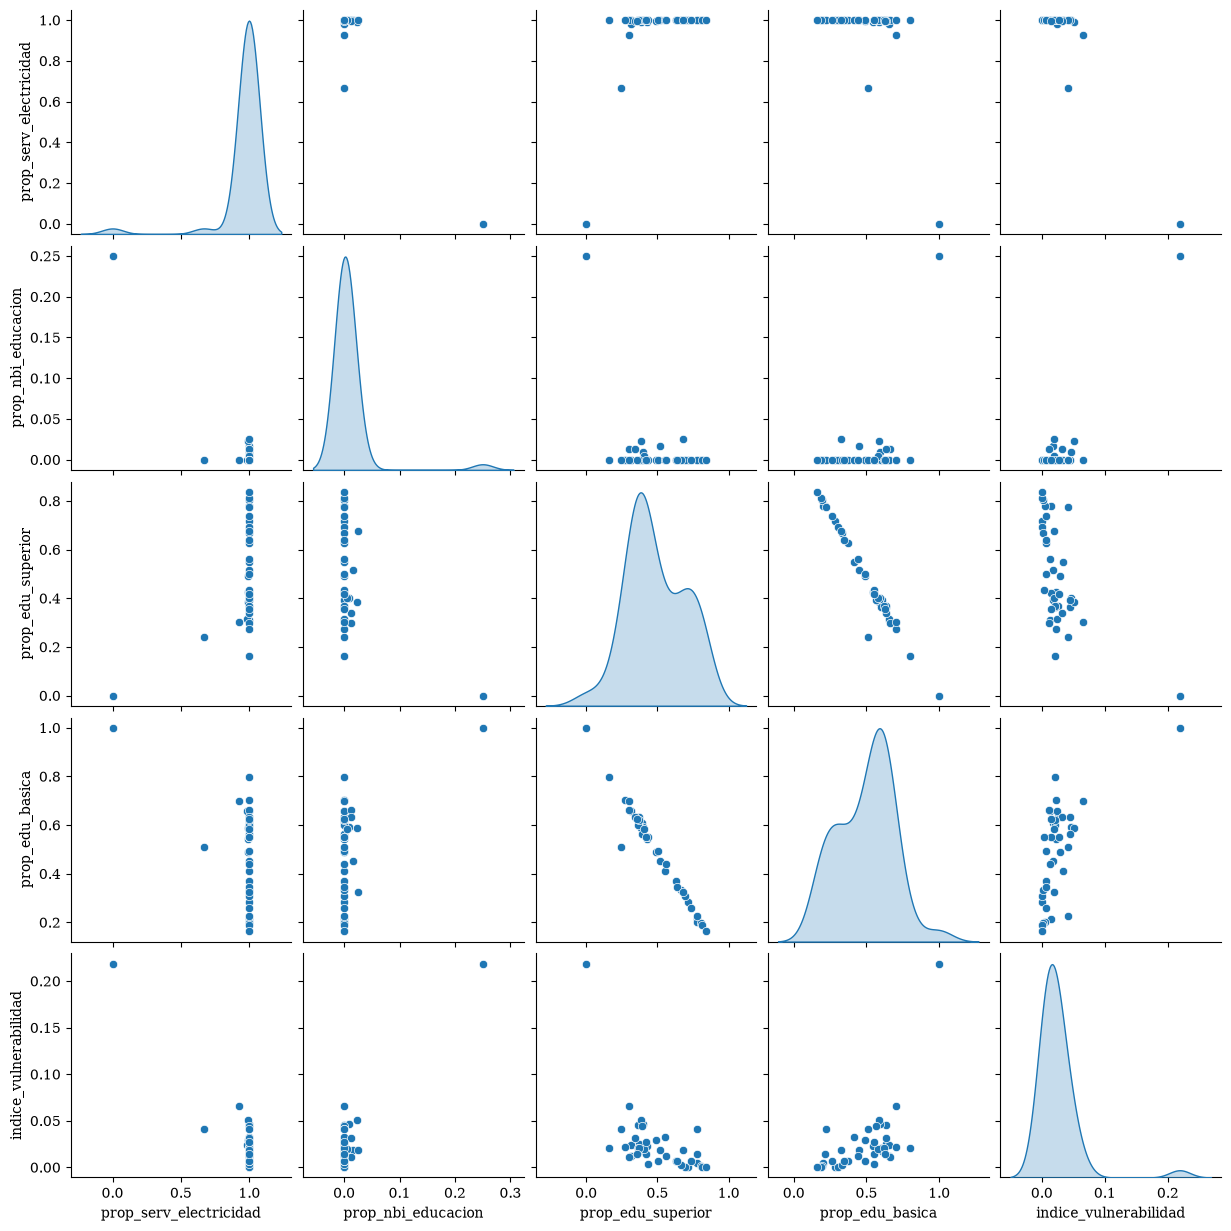

In [33]:
# crear gráfico de dispersion entre variables con alta correlación como matriz, ver densidad
sns.pairplot(X_reducido, diag_kind="kde")
plt.savefig("pairplot_variables_alta_correlacion.png", dpi=300, bbox_inches='tight')
plt.show()

Como podemos ver, primero, la distribución de las variables es peculiar, son valores altamente uniformes, con algunos valores extremos en las colas. Las correlaciones son extrañas, debido posiblemente a la agregación por distritos.

### 4.4. Reducción de Dimensionalidad

Para poder explicar de mejor manera (sin las 27 variables dependientes), se procede a aplicar PCA

#### PCA

In [34]:
X = base_lima.select_dtypes(include=["float64"]).drop(columns=["prop_es_mujer", "media_edad","población", "TVM"])
y = base_lima["TVM"]

X.head()

,prop_viv_tipo,prop_tic_celular,prop_tic_internet,prop_agua_todos_dias,prop_serv_electricidad,prop_nbi_vivienda,prop_nbi_hacinamiento,prop_nbi_sshh,prop_nbi_educacion,prop_nbi_dependencia,...,prop_edu_superior,prop_edu_basica,prop_alfabetizacion_funcional,prop_lengua_materna_nativa,prop_tic_uso_internet,prop_tic_celular_propio,prop_salud_enfermedad_cronica,prop_tiene_limitacion,prop_tiene_seguro,indice_vulnerabilidad
732,0.556250,0.976131,0.916973,1.000000,1.000000,0.000000,0.033333,0.000000,0.016936,0.013091,...,0.515954,0.451159,0.979752,0.035892,0.814821,0.911587,0.679015,0.106950,0.918719,0.018298
733,0.592148,1.000000,0.970712,1.000000,1.000000,0.080930,0.029288,0.000000,0.000000,0.000000,...,0.393668,0.606332,0.968053,0.236464,0.914861,0.941230,0.603966,0.091554,0.972529,0.017438
734,0.749154,0.972569,0.916982,0.985018,0.992922,0.025982,0.038529,0.009524,0.000000,0.000000,...,0.426293,0.541621,0.959211,0.123733,0.757951,0.925321,0.543619,0.051855,0.916595,0.022389
735,0.360609,1.000000,0.638373,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.365840,0.634160,1.000000,0.000000,0.186915,1.000000,0.588520,0.031354,1.000000,0.045203
736,0.549146,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.715643,0.284357,1.000000,0.010297,0.936980,0.947572,0.630191,0.032402,0.838050,0.000000


In [35]:
import numpy as np

Varianza explicada por cada componente: [27.2 16.7 10.8  7.6  7.5  6.2  5.5  4.3  3.6  2.2  2.   1.5  1.3  0.9
  0.8  0.7  0.6  0.3  0.2  0.1  0.   0. ]%


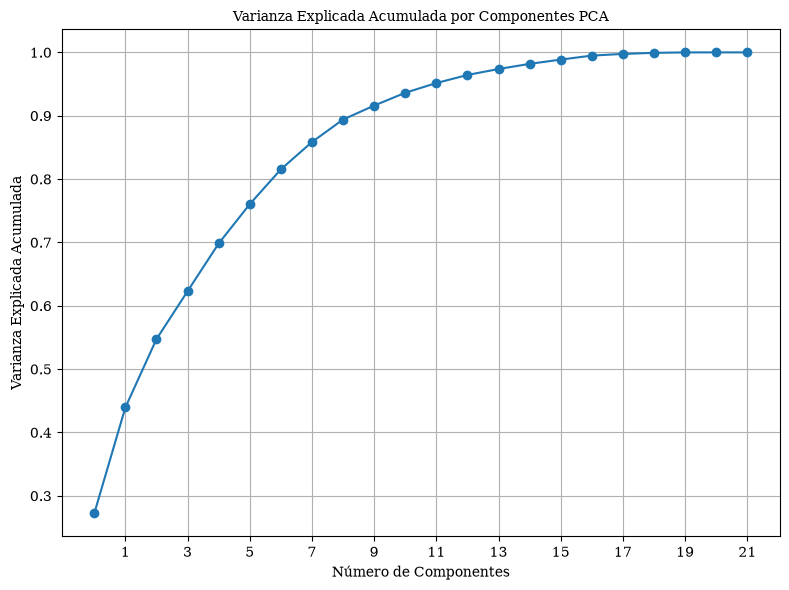

In [36]:
# hacer PCA para reducir dimensionalidad
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# estandarizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# aplicar PCA
pca = PCA(n_components=len(X.columns), random_state=42)  # Hacer PCA con el número máximo de componentes

X_pca = pca.fit_transform(X_scaled)

# mostrar varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_
print(f"Varianza explicada por cada componente: {varianza_explicada.round(3) * 100}%")

# graficar varianza explicada acumulada
plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(varianza_explicada), marker='o')
plt.title("Varianza Explicada Acumulada por Componentes PCA")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Explicada Acumulada")
plt.xticks(range(1, len(X.columns) + 1,2))
plt.grid()
plt.savefig("varianza_explicada_acumulada.png", dpi=300, bbox_inches='tight')
plt.show()

Con 3 componentes logramos explicar cerca del 60% de la varianza, por lo que será el número de componentes con los que nos quedaremos.

In [37]:
## generar dataframe de la varianza explicada acumulada
varianza_explicada = pd.DataFrame({'componente': range(1, len(pca.explained_variance_ratio_) + 1), 'varianza': pca.explained_variance_ratio_})
varianza_explicada['varianza_acumulada'] = varianza_explicada['varianza'].cumsum() * 100
varianza_explicada.drop(columns="varianza", inplace=True)
varianza_explicada

,componente,varianza_acumulada
0,1,27.215912
1,2,43.943447
2,3,54.730282
3,4,62.300788
4,5,69.830961
5,6,76.040204
6,7,81.537996
7,8,85.848581
8,9,89.399169
9,10,91.603890


In [38]:
# hacer PCA con 3 componentes
pca_3 = PCA(n_components=3, random_state=42)
X_pca_3 = pca_3.fit_transform(X_scaled)

# mostrar varianza explicada por cada componente
varianza_explicada_3 = pca_3.explained_variance_ratio_
print(f"Varianza explicada por cada componente (3 componentes): {varianza_explicada_3.round(3) * 100}%")

Varianza explicada por cada componente (3 componentes): [27.2 16.7 10.8]%


In [39]:
# visualizar cargas factoriales de las variables originales en los 3 componentes principales
cargas_factoriales = pd.DataFrame(
    pca_3.components_.T,
    columns=[f"Componente {i+1}" for i in range(3)],
    index=X.columns
)
print("Cargas factoriales de las variables originales en los 3 componentes principales:")
print(cargas_factoriales.round(3))

Cargas factoriales de las variables originales en los 3 componentes principales:
                               Componente 1  Componente 2  Componente 3
prop_viv_tipo                        -0.239        -0.256        -0.086
prop_tic_celular                     -0.025        -0.023         0.371
prop_tic_internet                    -0.234         0.113         0.230
prop_agua_todos_dias                  0.031         0.270         0.210
prop_serv_electricidad               -0.373        -0.000        -0.175
prop_nbi_vivienda                     0.297        -0.071        -0.158
prop_nbi_hacinamiento                -0.063        -0.299        -0.196
prop_nbi_sshh                        -0.032        -0.306        -0.219
prop_nbi_educacion                    0.380         0.012         0.033
prop_nbi_dependencia                 -0.019        -0.162        -0.055
prop_es_jefe                          0.304         0.097        -0.174
prop_en_pareja                       -0.257        -0.0

Nos quedamos con tres componentes, que dado sus cargas factoriales se pueden resumir como:
* PC1: desarrollo socioeconómico y educativo
* PC2: tipo de conectividad y perfil étnico-cultural
* PC3: acceso móvil e informalidad digital

In [40]:
X_pca_3_df = pd.DataFrame(X_pca_3, columns=[["PC1", "PC2", "PC3"]])

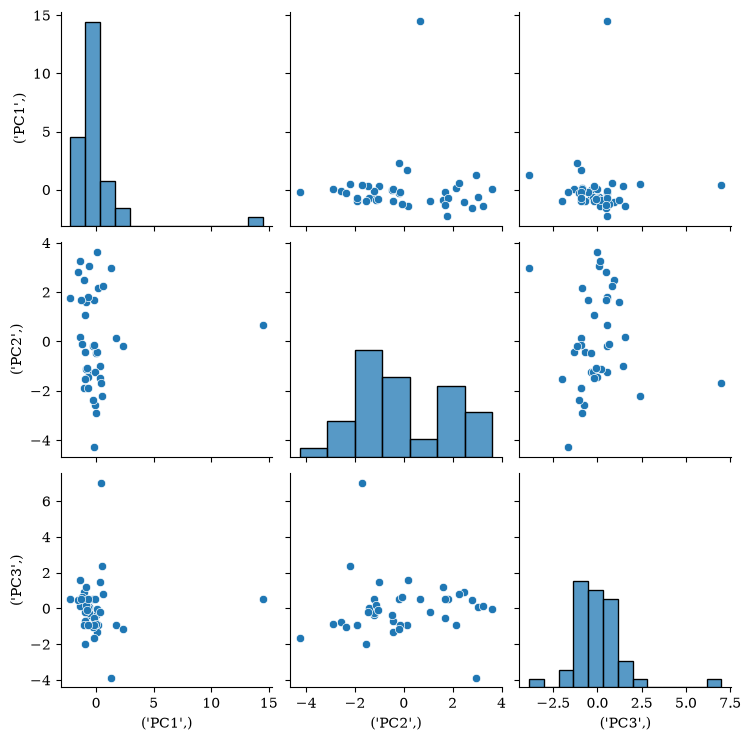

In [41]:
sns.pairplot(X_pca_3_df)
plt.show()

In [42]:
X_pca_3_df.describe().round(2)

,PC1,PC2,PC3
count,41.00,41.00,41.00
mean,-0.00,-0.00,-0.00
std,2.48,1.94,1.56
min,-2.25,-4.27,-3.88
25%,-0.95,-1.44,-0.90
50%,-0.30,-0.20,-0.11
75%,0.05,1.69,0.54
max,14.48,3.62,7.00


## Hacer NMF

In [43]:
# hacer NMF para reducir dimensionalidad a 3 componentes
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
nmf = NMF(n_components=3, init='random', random_state=42)
mm_scaler = MinMaxScaler()
X_mm_scaled = mm_scaler.fit_transform(X)
W = nmf.fit_transform(X_mm_scaled)

# mostrar componentes de NMF
H = nmf.components_
componentes_nmf = pd.DataFrame(
    H.T,
    columns=[f"Componente {i+1}" for i in range(3)],
    index=X.columns
)
print("Componentes de NMF (H):")
print(componentes_nmf.round(3))

Componentes de NMF (H):
                               Componente 1  Componente 2  Componente 3
prop_viv_tipo                         0.543         0.596         0.000
prop_tic_celular                      0.878         0.470         0.376
prop_tic_internet                     0.898         0.376         0.037
prop_agua_todos_dias                  1.049         0.171         0.502
prop_serv_electricidad                1.016         0.568         0.073
prop_nbi_vivienda                     0.000         0.113         0.478
prop_nbi_hacinamiento                 0.026         0.441         0.000
prop_nbi_sshh                         0.000         0.391         0.000
prop_nbi_educacion                    0.000         0.000         0.327
prop_nbi_dependencia                  0.000         0.171         0.000
prop_es_jefe                          0.277         0.133         0.363
prop_en_pareja                        0.731         0.453         0.098
prop_edu_superior                     0.

/home/goodgoy/Documents/01-universidad/01-data-mining/01-proyecto/.dm-proyecto-venv/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Para el caso de NMF obtenemos 3 componentes cuyos perfiles son los siguientes:
* Componente 1: Hogar conectado y desarrollado
* Componente 2: Conectividad básica e informal
* Componente 3: Precariedad y vulnerabilidad NBI

In [44]:
# renombrar columnas de W para identificar componentes
W_df = pd.DataFrame(
    W,
    columns=[['Componente 1','Componente 2','Componente 3']]
)

W_df.describe().round(2)

,Componente 1,Componente 2,Componente 3
count,41.00,41.00,41.00
mean,0.67,0.46,0.20
std,0.24,0.37,0.37
min,0.00,0.00,0.00
25%,0.53,0.09,0.03
50%,0.62,0.48,0.09
75%,0.87,0.71,0.18
max,1.09,1.40,2.28


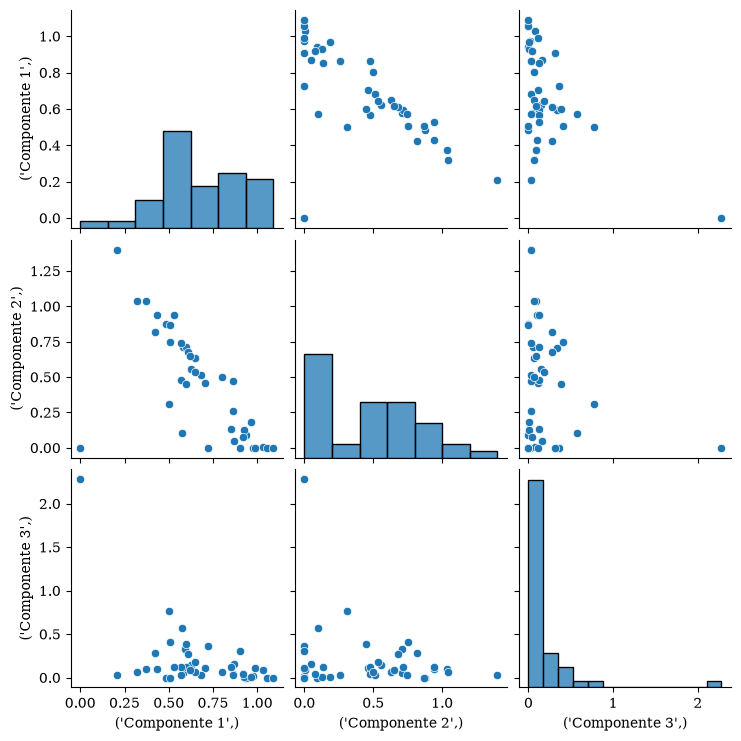

In [45]:
sns.pairplot(W_df)
plt.show()

### 4.5. Clustering

#### Clustering con KMeans

In [46]:
X_pca_3_df.columns = [col[0] if isinstance(col, tuple) else col
                      for col in X_pca_3_df.columns]

##### Clustering con PCA

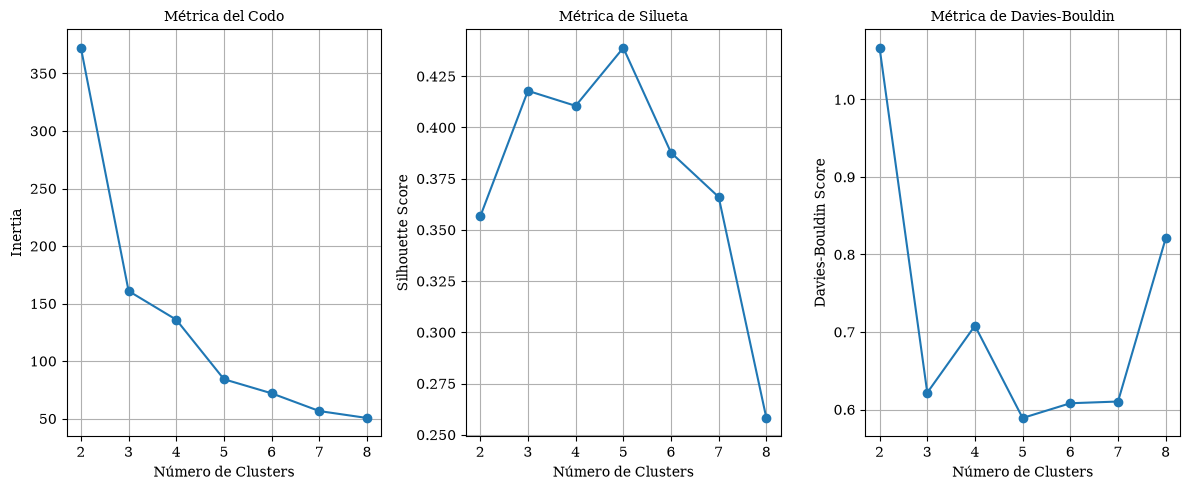

In [47]:
# probar con distintos k de 2 a 8
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

kmeans = [KMeans(n_clusters=i, random_state=42) for i in range(2, 9)]

# metrica del codo
inertia = [model.fit(X_pca_3).inertia_ for model in kmeans]

# metrica de silueta
silhouette_scores = [silhouette_score(X_pca_3, model.fit(X_pca_3).labels_) for model in kmeans]

# metrica de Davies-Bouldin
davies_bouldin_scores = [davies_bouldin_score(X_pca_3, model.fit(X_pca_3).labels_) for model in kmeans]

# graficar métricas
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.plot(range(2, 9), inertia, marker='o')
plt.title("Métrica del Codo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inertia")
plt.grid()
plt.subplot(1, 3, 2)
plt.plot(range(2, 9), silhouette_scores, marker='o')
plt.title("Métrica de Silueta")
plt.xlabel("Número de Clusters")
plt.ylabel("Silhouette Score")
plt.grid()
plt.subplot(1, 3, 3)
plt.plot(range(2, 9), davies_bouldin_scores, marker='o')
plt.title("Métrica de Davies-Bouldin")
plt.xlabel("Número de Clusters")
plt.ylabel("Davies-Bouldin Score")
plt.grid()
plt.savefig("metricas_kmeans.png", dpi=300, bbox_inches='tight')
plt.show()

In [48]:
# realizar clustering con KMeans usando los componentes de PCA
from sklearn.cluster import KMeans

kmeans_pca = KMeans(n_clusters=5, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca_3_df)
base_lima["cluster_pca"] = clusters_pca

# realizar clustering con KMeans usando los componentes de NMF
kmeans_nmf = KMeans(n_clusters=5, random_state=42)
clusters_nmf = kmeans_nmf.fit_predict(W_df)
base_lima["cluster_nmf"] = clusters_nmf

# visualizar clusters en el espacio de los componentes PCA en 3 dimensiones 
import plotly.express as px

fig = px.scatter_3d(
    data_frame=X_pca_3_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color=base_lima["cluster_pca"].astype(str),
    width=800,
    height=600,
    title="Clustering KMeans en Componentes PCA",
    labels={
        "PC1": "PC1",
        "PC2": "PC2",
        "PC3": "PC3",
        "color": "Cluster"
    }
)

fig.show()

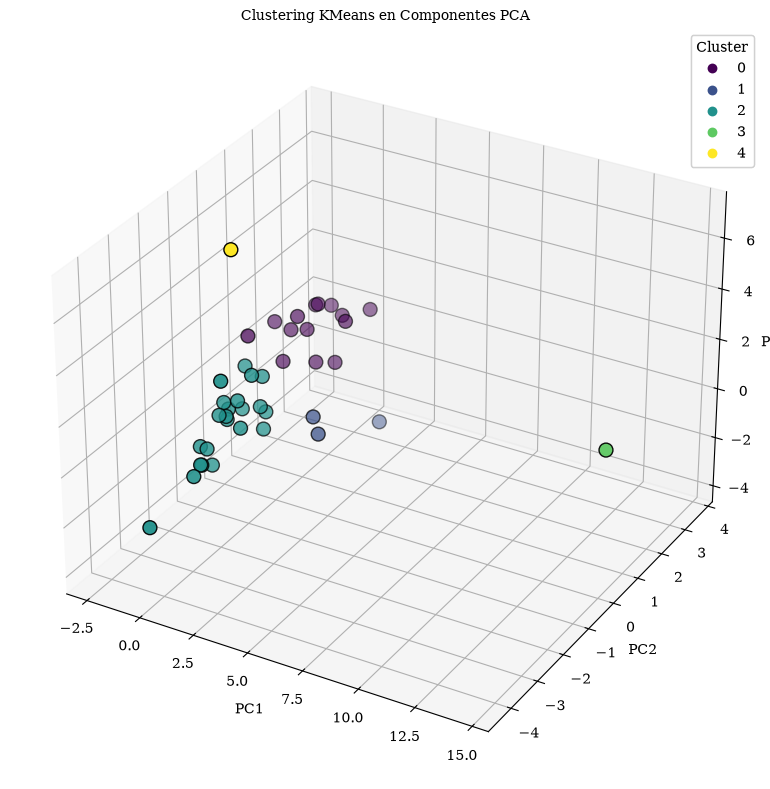

In [49]:
# visualizar clusters en el espacio de los componentes PCA en 3 dimensiones con matplotlib
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca_3_df["PC1"],
    X_pca_3_df["PC2"],
    X_pca_3_df["PC3"],
    c=base_lima["cluster_pca"],
    cmap="viridis",
    s=100,
    edgecolor='k'
)
ax.set_title("Clustering KMeans en Componentes PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.savefig("cluster_pca_3d.png", dpi=300, bbox_inches='tight')
plt.show()

El cluester 0 tiene una menor identidad cultural y mayor desarrollo socioeconómico que el cluester 1. Ambos presentan valores similares de acceso móvil. Un tercer cluster 2, tiene menor perfil cultural, bajo desarrollo socioeconómico y regular acceso móvil.

##### Clustering con NMF

In [50]:
W_df.columns = [col[0] if isinstance(col, tuple) else col
                      for col in W_df.columns]

In [51]:
# visualizar clusters en el espacio de los componentes NMF en 3 dimensiones
import plotly.express as px
fig = px.scatter_3d(
    W_df,
    x="Componente 1",
    y="Componente 2",
    z="Componente 3",
    color=base_lima["cluster_nmf"].astype(str),
    title="Clustering KMeans en Componentes NMF",
    labels={
        "x": "Componente 1",
        "y": "Componente 2",
        "z": "Componente 3"
    },
    width=800,
    height=600
)
#fig.write_image("clustering_nmf_3d.png", scale=2)
fig.show()

Los tres clusteres presentan un bajo nivel de precariedad y se distinguen básicamente por la conectividad.
El cluester 0 tiene un hogar conectado y está instruido.
El cluster 2 medianamente conectado y letrado enr edes.
El cluster 1 de manera similar.

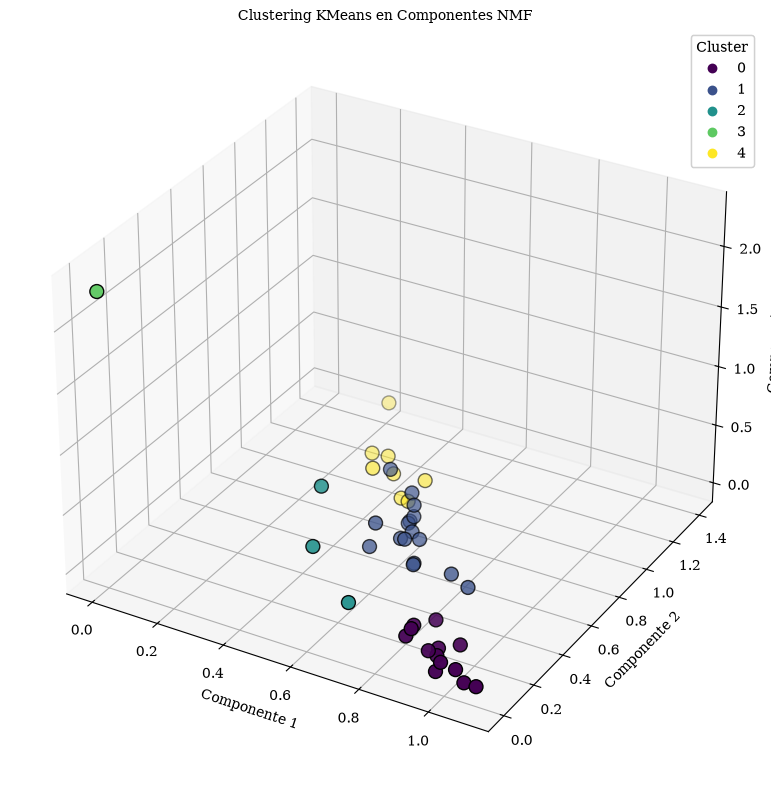

In [52]:
# visualizar clusters en el espacio de los componentes NMF en 3 dimensiones con matplotlib
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    W_df['Componente 1'],
    W_df['Componente 2'],
    W_df['Componente 3'],
    c=base_lima["cluster_nmf"],
    cmap='viridis',
    edgecolor='k',
    s=100
)
ax.set_title("Clustering KMeans en Componentes NMF")
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.set_zlabel("Componente 3")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.savefig("clustering_nmf_3d.png", dpi=300, bbox_inches='tight')
plt.show()